In [50]:
from matplotlib import pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from math import sqrt

In [51]:
# Download do Dataset

# Remove qualquer arquivo que comece com 'FuelConsumption' (evita o erro de "No such file")
!rm -f FuelConsumptionCo2.csv*

!pip3 install wget

!wget https://raw.githubusercontent.com/diogocortiz/Curso-IA-para-todos/refs/heads/master/RegressaoLinear/FuelConsumptionCo2.csv

--2026-03-18 22:21:23--  https://raw.githubusercontent.com/diogocortiz/Curso-IA-para-todos/refs/heads/master/RegressaoLinear/FuelConsumptionCo2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/plain]
Saving to: ‘FuelConsumptionCo2.csv’

FuelConsumptionCo2. 100%[===================>]  70.93K  --.-KB/s    in 0.01s   

2026-03-18 22:21:24 (7.05 MB/s) - ‘FuelConsumptionCo2.csv’ saved [72629/72629]



In [52]:
# Carregar o dataset para um DataFrame (Pandas)

# Carregando o CSV
df = pd.read_csv('FuelConsumptionCo2.csv')

df.head()


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [53]:
df.isnull().sum()

,0
MODELYEAR,0
MAKE,0
MODEL,0
VEHICLECLASS,0
ENGINESIZE,0
CYLINDERS,0
TRANSMISSION,0
FUELTYPE,0
FUELCONSUMPTION_CITY,0
FUELCONSUMPTION_HWY,0


In [54]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [55]:
df.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')

In [56]:
motores=df[['ENGINESIZE']]
co2=df[['CO2EMISSIONS']]

In [57]:
motores.head()

,ENGINESIZE
0,2.0
1,2.4
2,1.5
3,3.5
4,3.5


In [58]:
co2.head()

,CO2EMISSIONS
0,196
1,221
2,136
3,255
4,244


In [59]:
# Dividir o dataset em dados de treinamento e dados de teste

x_treino,x_teste,y_treino,y_teste=train_test_split(motores,co2,test_size=0.2,random_state=42)

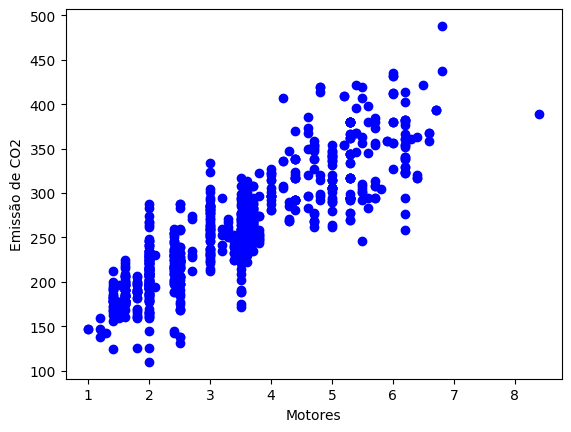

In [60]:
# Exibir a correlação entre as features do dataset de treinamento

plt.scatter(x_treino,y_treino,color="blue")
plt.xlabel("Motores")
plt.ylabel("Emissão de CO2")
plt.show()

In [61]:
# Treinamento de um modelo de regressão linear

modelo=linear_model.LinearRegression()
modelo.fit(x_treino,y_treino)

LinearRegression()

In [62]:
## Exibir os coeficientes (a e b)

b=modelo.intercept_[0]
a=modelo.coef_[0][0]

print(f'{a}*x+{b}')

38.992978724434074*x+126.28970217408721


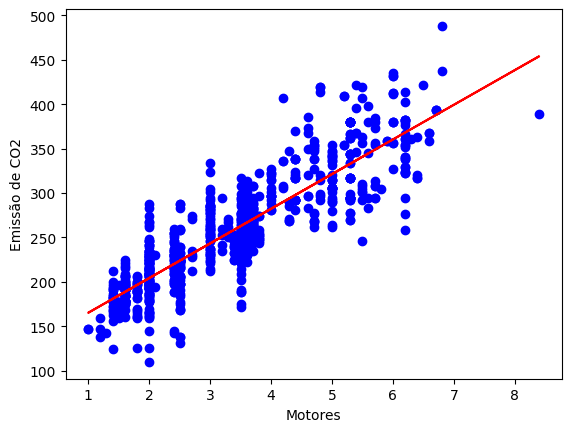

In [63]:
## Exibir a reta de regressão no dataset de treino

plt.scatter(x_treino,y_treino,color="blue")
plt.plot(x_treino,a*x_treino+b,'-r')
plt.xlabel("Motores")
plt.ylabel("Emissão de CO2")
plt.show()

In [64]:
## Executar o modelo no dataset de teste

predicoesCO2=modelo.predict(x_teste)

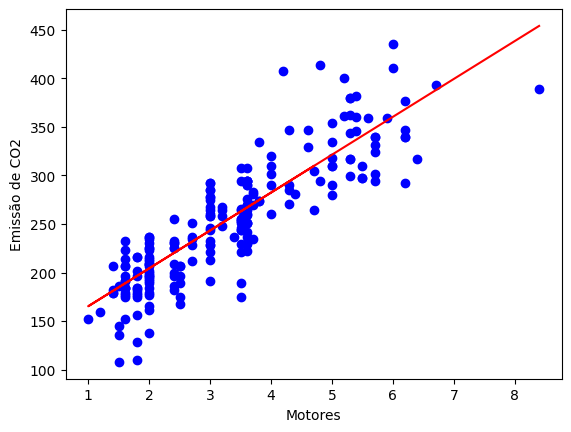

In [65]:
## Exibir a reta de regressão no dataset de teste

plt.scatter(x_teste,y_teste,color="blue")
plt.plot(x_teste,a*x_teste+b,'-r')
plt.xlabel("Motores")
plt.ylabel("Emissão de CO2")
plt.show()


In [72]:
## Avaliação do modelo

sse = np.sum((predicoesCO2 - y_teste)**2,axis=0)
print(f"SSE: {sse.item():.2f}")

mse=mean_squared_error(y_teste,predicoesCO2)
print(f"MSE: {mse:.2f}")

r2=r2_score(y_teste,predicoesCO2)
print(f"R2: {r2:.2f}")

SSE: 210990.77
MSE: 985.94
R2: 0.76
